Target Identification Notebook
==============================

This notebook demonstrates how to use the OpenCSP SpotAnalysis framework to locate a target board within an image and do basic analysis on the image. Features of this notebook are:

1. Average many images.
2. Locate a target board.
3. Subtract a null (non-sun) image from an illuminated (on-sun) image.
4. Inpaint (fill in) part of an image that has bad data.
5. Create plots for false color, hot spot (center), cross section.
6. Generate a powerpoint deck for this example.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import configparser
import cv2 as cv
import numpy as np
import os
import PIL.Image as Image
import re

from opencsp import opencsp_settings
import contrib.common.lib.cv.annotations.EnclosedEnergyAnnotations as eeanno
import opencsp.common.lib.cv.annotations.HotspotAnnotation as hanno
from opencsp.common.lib.cv.CacheableImage import CacheableImage
import opencsp.common.lib.cv.image_reshapers as ir
from contrib.common.lib.cv.spot_analysis.image_processor import *
from opencsp.common.lib.cv.spot_analysis.image_processor import *
import opencsp.common.lib.cv.spot_analysis.SpotAnalysisOperable as sao
import opencsp.common.lib.cv.SpotAnalysis as sa
import opencsp.common.lib.opencsp_path.opencsp_root_path as orp
import opencsp.common.lib.render.Color as clr
import opencsp.common.lib.tool.file_tools as ft
import opencsp.common.lib.tool.image_tools as it
import contrib.common.lib.tool.ImageGrid as ig
import opencsp.common.lib.tool.log_tools as lt
import opencsp.common.lib.tool.unit_conversion as uc

Data Paths
----------

Copy experment_settings_example.ini to experiment_setting.ini and update the paths to match where the data is located on your computer.

In [3]:
experiment_settings_file = r"C:\ctemp\OpenCSP_example_data\target_identification\input\target_identification_settings_ctemp.ini"
if not ft.file_exists(experiment_settings_file):
    raise FileNotFoundError("File '" + experiment_settings_file + "' does not exist.")

experiment_settings = configparser.ConfigParser()
experiment_settings.read(experiment_settings_file)

nosun_dir  = experiment_settings["Default"]["nosun_dir"]
nosun_desc = experiment_settings["Default"]["nosun_desc"]
onsun_dir  = experiment_settings["Default"]["onsun_dir"]
onsun_desc = experiment_settings["Default"]["onsun_desc"]
mask_image_path_name_ext = experiment_settings["Default"]["mask_image_path_name_ext"]

output_dir = experiment_settings["Default"]["output_dir"]

# Echo input information.
print('nosun_dir  = ', nosun_dir)
print('nosun_desc = ', nosun_desc)
print('onsun_dir  = ', onsun_dir)
print('onsun_desc = ', onsun_desc)
print('mask_image_path_name_ext = ', mask_image_path_name_ext)

print('output_dir = ', output_dir)

nosun_dir  =  C:\ctemp\OpenCSP_example_data\target_identification\input\HeliostatPointing\2_Data\NoSun
nosun_desc =  No Sun
onsun_dir  =  C:\ctemp\OpenCSP_example_data\target_identification\input\HeliostatPointing\2_Data\OnSun
onsun_desc =  9E10
mask_image_path_name_ext =  C:\ctemp\OpenCSP_example_data\target_identification\input\HeliostatPointing\1_Plan\target_board_mask.png
output_dir =  C:\ctemp\OpenCSP_example_data\target_identification\output


In [4]:
# check for missing directories
if not ft.directory_exists(nosun_dir):
    lt.error_and_raise(
        FileNotFoundError, f"Error in target_identification: images directory {nosun_dir} not found!"
    )
if not ft.directory_exists(onsun_dir):
    lt.error_and_raise(
        FileNotFoundError, f"Error in target_identification: images directory {onsun_dir} not found!"
    )

# Provide output directory.
ft.create_directories_if_necessary(output_dir)

Data Processing
---------------

Everything above this line is set up, and everything below this line is analysis.

The following cell locates images from the directories specified in `experiment_settings.ini`.

In [5]:
# Get the name.ext for the images
nosun_images_name_ext = it.image_files_in_directory(ft.join(nosun_dir, "PixelData_Images"))
onsun_images_name_ext = it.image_files_in_directory(ft.join(onsun_dir, "PixelData_Images"))
if len(nosun_images_name_ext) == 0 or len(onsun_images_name_ext) == 0:
    lt.error_and_raise(
        FileNotFoundError,
        f"In target_identification: "
        + "found {len(heliostat_images_name_ext)} heliostat images and {len(nosun_images_name_ext)} nosun images!",
    )

# ...and prepend the path
nosun_images_pne = [ft.join(nosun_dir, "PixelData_Images", ne) for ne in nosun_images_name_ext]
onsun_images_pne = [ft.join(onsun_dir, "PixelData_Images", ne) for ne in onsun_images_name_ext]

# Report what was found.
print("No sun images:")
for nosun_image_path_name_ext in nosun_images_pne:
    print("    ", nosun_image_path_name_ext)
print("On sun images:")
for onsun_image_path_name_ext in onsun_images_pne:
    print("    ", onsun_image_path_name_ext)

No sun images:
     C:\ctemp\OpenCSP_example_data\target_identification\input\HeliostatPointing\2_Data\NoSun\PixelData_Images\20240613_122801.91_10E10_Raw.png
     C:\ctemp\OpenCSP_example_data\target_identification\input\HeliostatPointing\2_Data\NoSun\PixelData_Images\20240613_122802.91_10E10_Raw.png
     C:\ctemp\OpenCSP_example_data\target_identification\input\HeliostatPointing\2_Data\NoSun\PixelData_Images\20240613_122803.90_10E10_Raw.png
     C:\ctemp\OpenCSP_example_data\target_identification\input\HeliostatPointing\2_Data\NoSun\PixelData_Images\20240613_122804.91_10E10_Raw.png
     C:\ctemp\OpenCSP_example_data\target_identification\input\HeliostatPointing\2_Data\NoSun\PixelData_Images\20240613_122805.91_10E10_Raw.png
On sun images:
     C:\ctemp\OpenCSP_example_data\target_identification\input\HeliostatPointing\2_Data\OnSun\PixelData_Images\20240613_122055.39_09E10_Raw.png
     C:\ctemp\OpenCSP_example_data\target_identification\input\HeliostatPointing\2_Data\OnSun\PixelData_Im

Average and blur the input images.

Averaging reduces the camera noise floor. Blurring the images reduces the camera shake and atmospheric distortion noise floor.

Processing image 20240613_122801.91_10E10_Raw.png
Processing image 20240613_122802.91_10E10_Raw.png
Processing image 20240613_122803.90_10E10_Raw.png
Processing image 20240613_122804.91_10E10_Raw.png
Processing image 20240613_122805.91_10E10_Raw.png
In AverageByGroupImageProcessor._execute_aggregate(): averaging 5 images
Processing image 20240613_122055.39_09E10_Raw.png
Processing image 20240613_122056.38_09E10_Raw.png
Processing image 20240613_122057.39_09E10_Raw.png
Processing image 20240613_122058.39_09E10_Raw.png
Processing image 20240613_122059.39_09E10_Raw.png
In AverageByGroupImageProcessor._execute_aggregate(): averaging 5 images

Left: average and blurred no-sun image
Right: average and blurred on-sun image


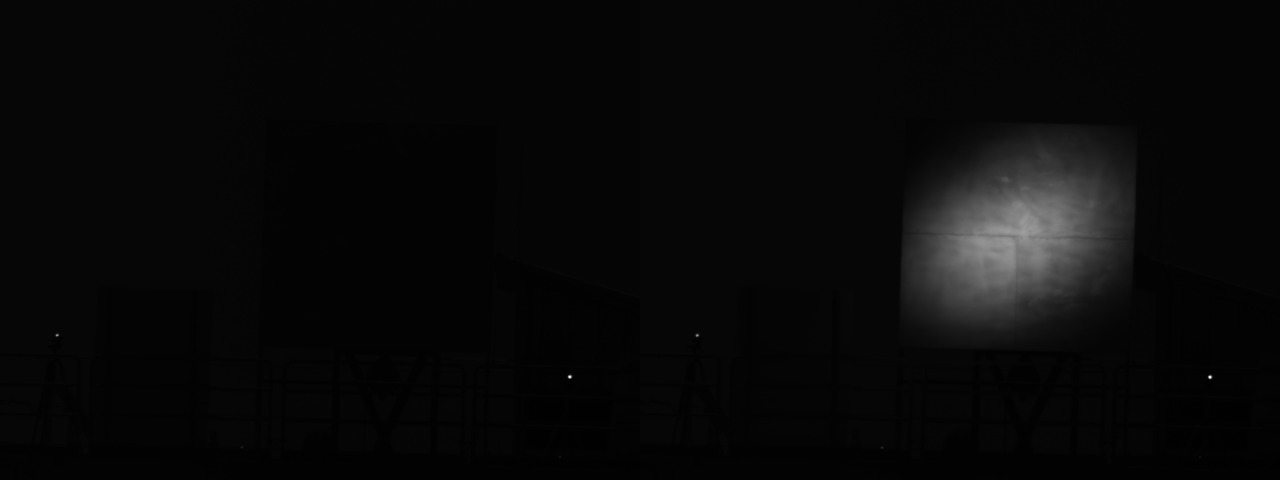

In [6]:
def build_preprocessing_pipeline(input_images: list) -> sa.SpotAnalysis:
    # Define the image processors, including the order in which they
    # are executed (python dictionaries preserve order).
    image_processors = {
        "Echo": EchoImageProcessor(),
        "Avg": AverageByGroupImageProcessor(),
        "Blur": ConvolutionImageProcessor(),
    }
    spot_analysis = sa.SpotAnalysis("Preprocessing", list(image_processors.values()))
    spot_analysis.set_primary_images(input_images)
    return spot_analysis


# process the no-sun images
# note: we will only have one "processed" operable as a result of the "Avg" image processor
nosun_sa = build_preprocessing_pipeline(nosun_images_pne)
for processed in nosun_sa:
    nosun_img = processed.primary_image.to_image()
    nosun_img_file = ft.join(output_dir, ft.convert_string_to_file_body(nosun_desc + "_avg.png"))
    nosun_img.save(nosun_img_file)

# process the on-sun images
# note: we will only have one "processed" operable as a result of the "Avg" image processor
onsun_sa = build_preprocessing_pipeline(onsun_images_pne)
for processed in onsun_sa:
    onsun_img = processed.primary_image.to_image()
    onsun_img_file = ft.join(output_dir, ft.convert_string_to_file_body(onsun_desc + "_onsun_avg.png"))
    onsun_img.save(onsun_img_file)

# preview the averaged images
print("\nLeft: average and blurred no-sun image\nRight: average and blurred on-sun image")
onsun_img.show()
nosun_img.show()

ig.ImageGrid(
    (2, 1),
    nosun_img,
    onsun_img,
    subimage_size=(640, 480)
).tile_images()

The output below shows the result of subtracting the no-sun image from the on-sun image.

In some of our other examples we'd subtract an additional, small value from the entire image until the surrounding was entirely black. We don't need to do that here, because the target detector, hotspot locator, and other algorithms we're using aren't sensitive to small pixel values.

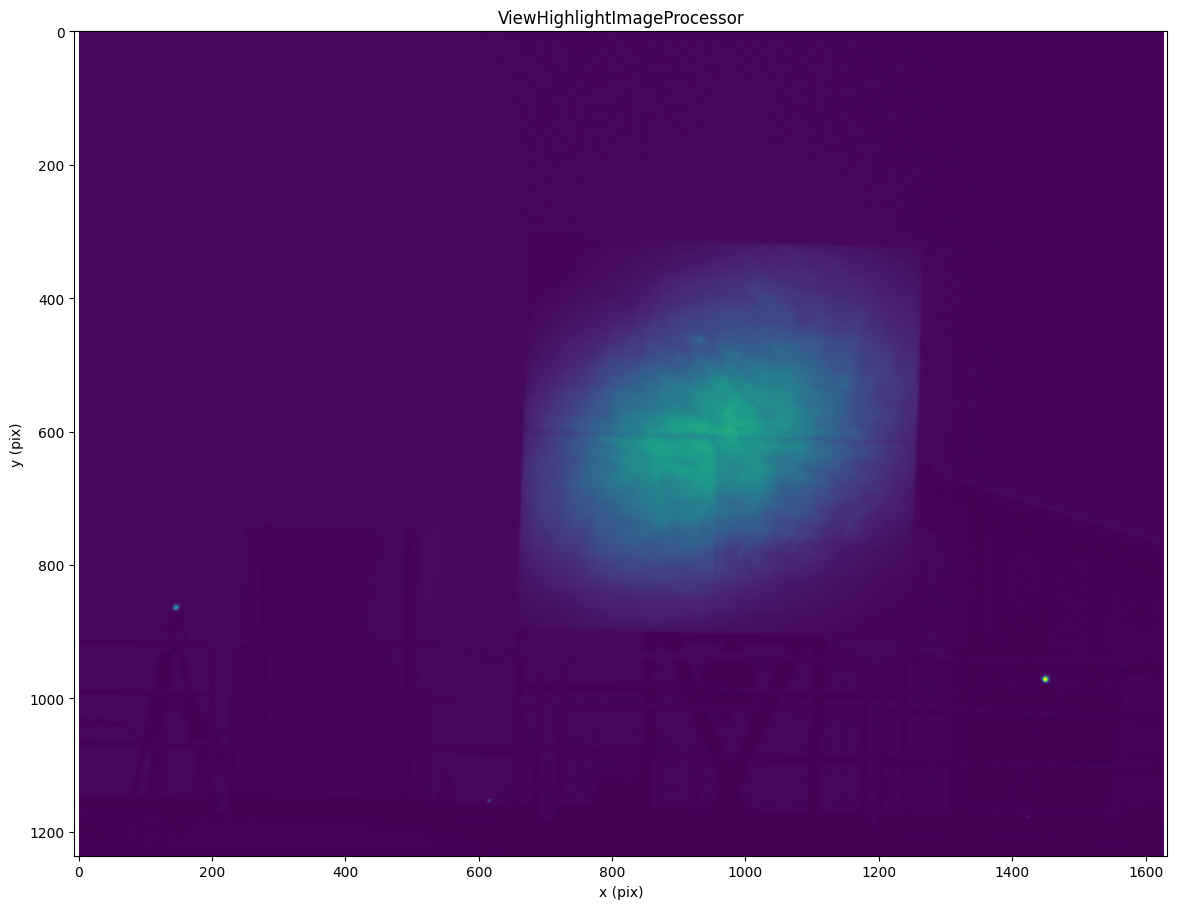

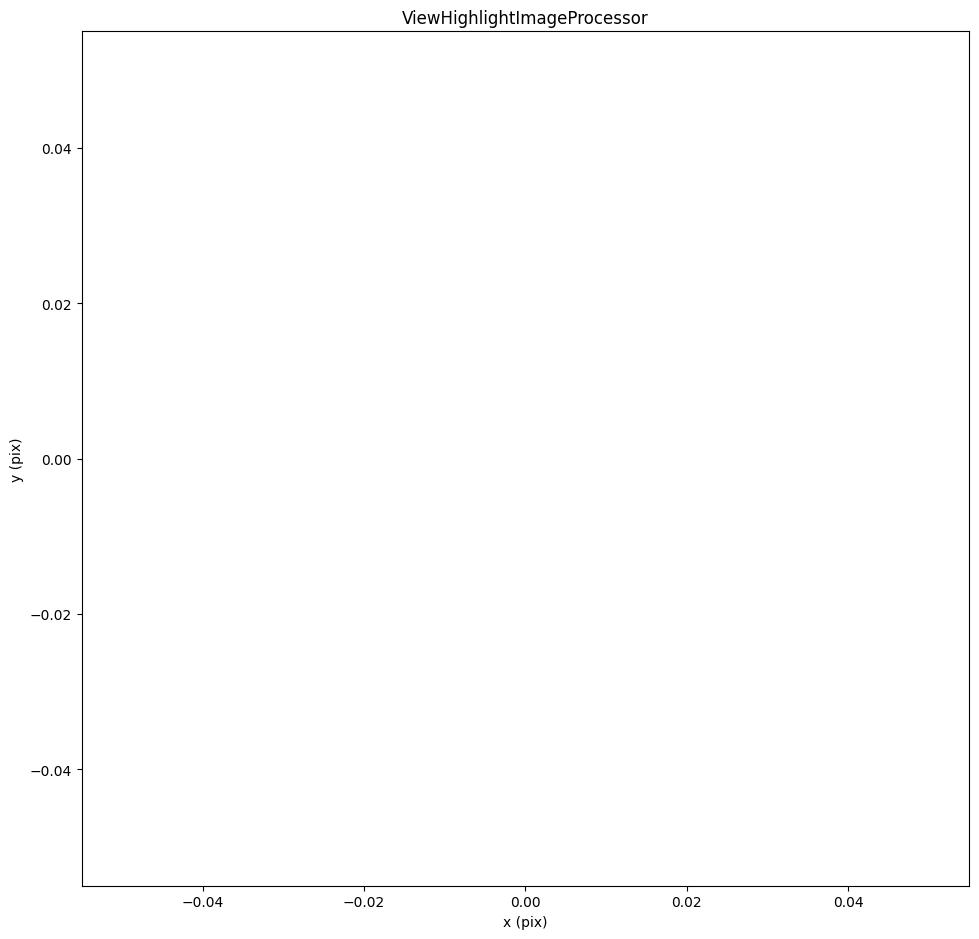

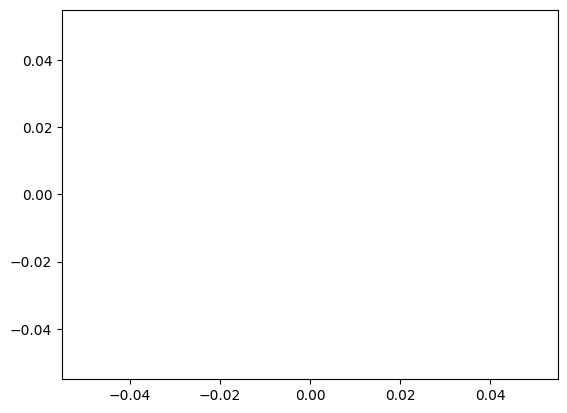


Left: average and blurred on-sun image
Right: on-sun image after subtracting the no-sun


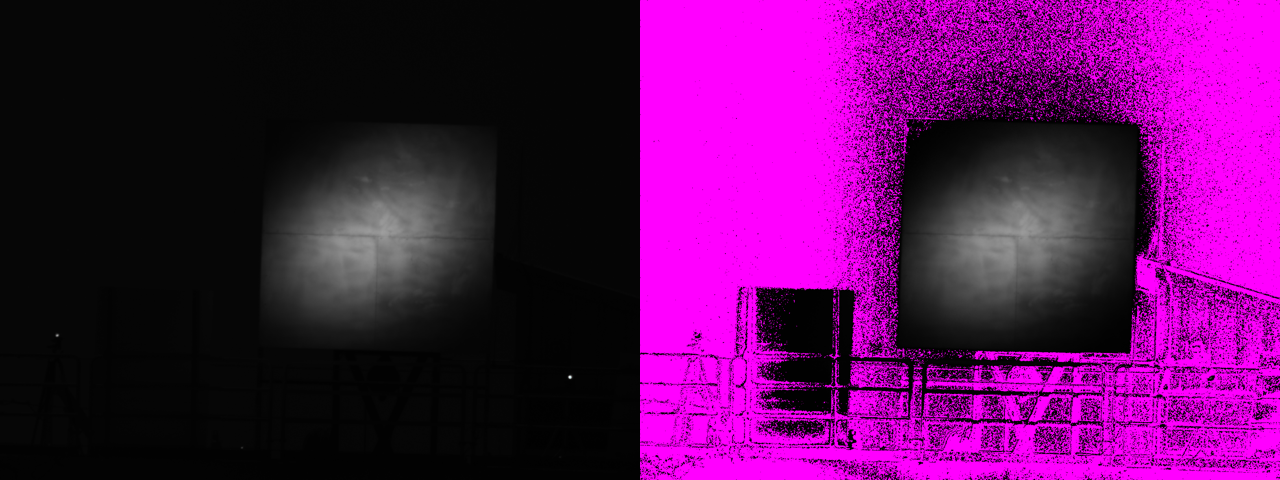

In [7]:
procs_nsub = {
    "VHighlightRaw": ViewHighlightImageProcessor(),
    "SubNull": NullImageSubtractionImageProcessor(np.array(nosun_img)),
    "VHighlightNsub": ViewHighlightImageProcessor(),
}

spot_analysis_nsub = sa.SpotAnalysis("NullSub", list(procs_nsub.values()))
spot_analysis_nsub.set_primary_images([onsun_img]);

for processed in spot_analysis_nsub:
    result_onsun_highlight = processed.visualization_images[procs_nsub["VHighlightRaw"]][-1]
    image_onsun_highlight = result_onsun_highlight.to_image()
    result_nullsub = processed.visualization_images[procs_nsub["VHighlightNsub"]][-1]
    image_nullsub = result_nullsub.to_image()

# preview the images with values subtracted and absolute blacks highlighted
print("\nLeft: average and blurred on-sun image" + "\nRight: on-sun image after subtracting the no-sun")

ig.ImageGrid(
    (2, 1),
    image_onsun_highlight,
    image_nullsub,
    subimage_size=(640, 480)
).tile_images()


In the following cell we test out a few steps for [Canny edge detection](https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html) values. We test combinations of 4, 6, and 8 for the edges gradient, and 2, 4, and 6 for the non-edges gradient. The resulting edges found for the gradients are displayed in a separate window.

In AverageByGroupImageProcessor._execute_aggregate(): averaging 1 images


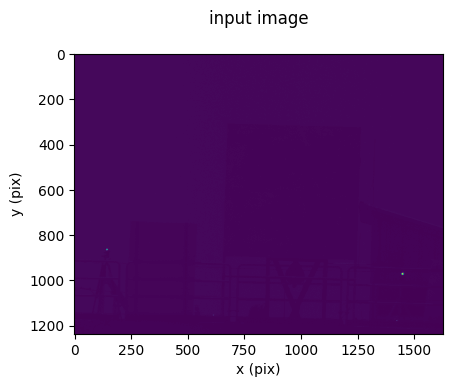

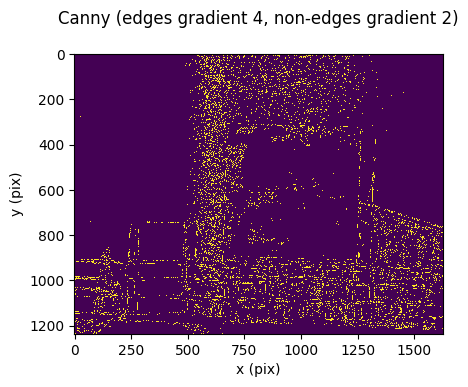

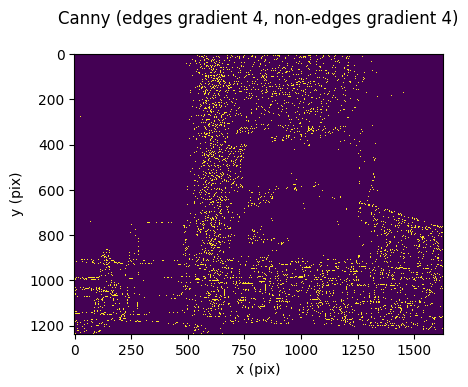

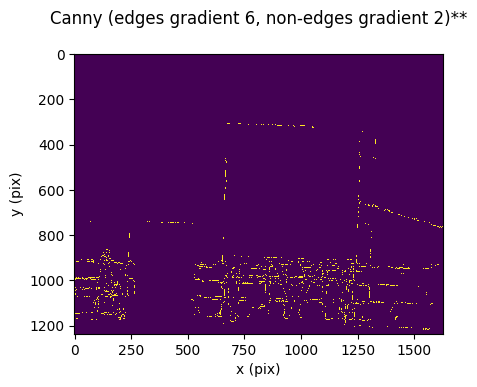

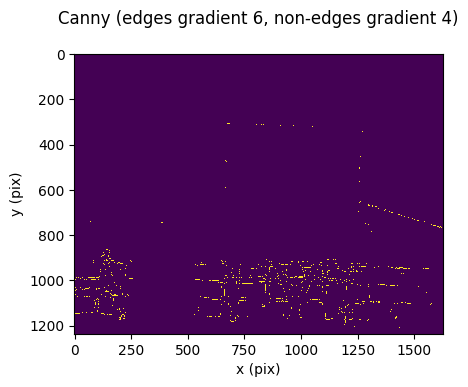

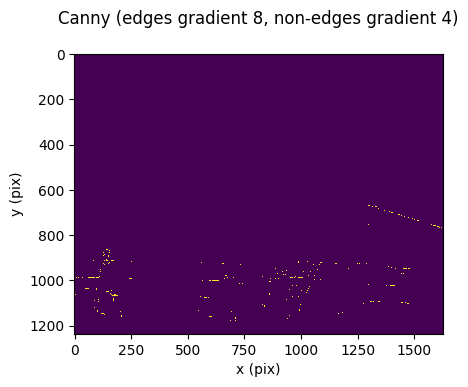

Showing images to user and waiting...


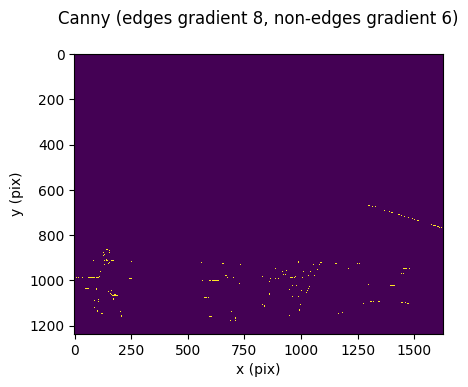

...done
Sampled 667 points
In TargetBoardLocatorImageProcessor: corners are {'tl': 2D Point:
array([[674.53074488],
       [304.9803289 ]]), 'tr': 2D Point:
array([[1262.48428214],
       [ 322.70654771]]), 'br': 2D Point:
array([[1244.37376296],
       [ 910.048451  ]]), 'bl': 2D Point:
array([[654.55339572],
       [889.50443473]])}


In [8]:
best_canny_edges_gradient = 6
best_canny_non_edges_gradient = 2
tbl_proc = TargetBoardLocatorImageProcessor(
    reference_image_dir_or_file=nosun_img_file,
    cropped_x1x2y1y2=None,
    target_width_meters=uc.foot_to_meter(8),
    target_height_meters=uc.foot_to_meter(8),
    canny_edges_gradient=best_canny_edges_gradient,
    canny_non_edges_gradient=best_canny_non_edges_gradient,
    edge_coarse_width=30,
    canny_test_gradients=[(4, 2), (4, 4), (6, 2), (6, 4), (8, 4), (8, 6)],
    generate_region_detector_powerpoint=False,
)

spot_analysis_canny = sa.SpotAnalysis("Canny Parameter Testing", [tbl_proc])
spot_analysis_canny.set_primary_images([onsun_img_file])
processed = next(iter(spot_analysis_canny))

The following shows the steps taken to locate the target board. Those steps include:

1. Canny edge detection: locates pixels that are likely to be edges
2. Edge blob analysis: expands and contracts the edge pixels in the horizontal and vertical axes to select down to pixels that are likely to be edges in those axes.
3. Boundary pixel identification: finds the edge pixels that define the boundary by casting rays from the center of the expected target board area out to the edges.
4. Boundary pixel grouping: groups the pixels found with the ray cast into left/right/top/bottom selections.
5. RanSaC edge definition: runs [random sample consensus](https://en.wikipedia.org/wiki/Random_sample_consensus) to assign a best fit line to the four edge groups.
6. Perspective transform and crop: builds a Perspective Transform (/common/lib/cv/PerspectiveTransform.py) instance to translate between pixels and meters.

In AverageByGroupImageProcessor._execute_aggregate(): averaging 1 images
Sampled 690 points
In TargetBoardLocatorImageProcessor: corners are {'tl': 2D Point:
array([[674.53074488],
       [304.9803289 ]]), 'tr': 2D Point:
array([[1262.48428214],
       [ 322.70654771]]), 'br': 2D Point:
array([[1244.37293522],
       [ 910.07529536]]), 'bl': 2D Point:
array([[654.55391284],
       [889.4893044 ]])}

Top-left 1 Canny, middle 2 edge pixels, right boundary pixels/ray casting
Bottom-Left 4 boundary grouping, middle 5 RanSaC edge assignment, right 6 perspective transform


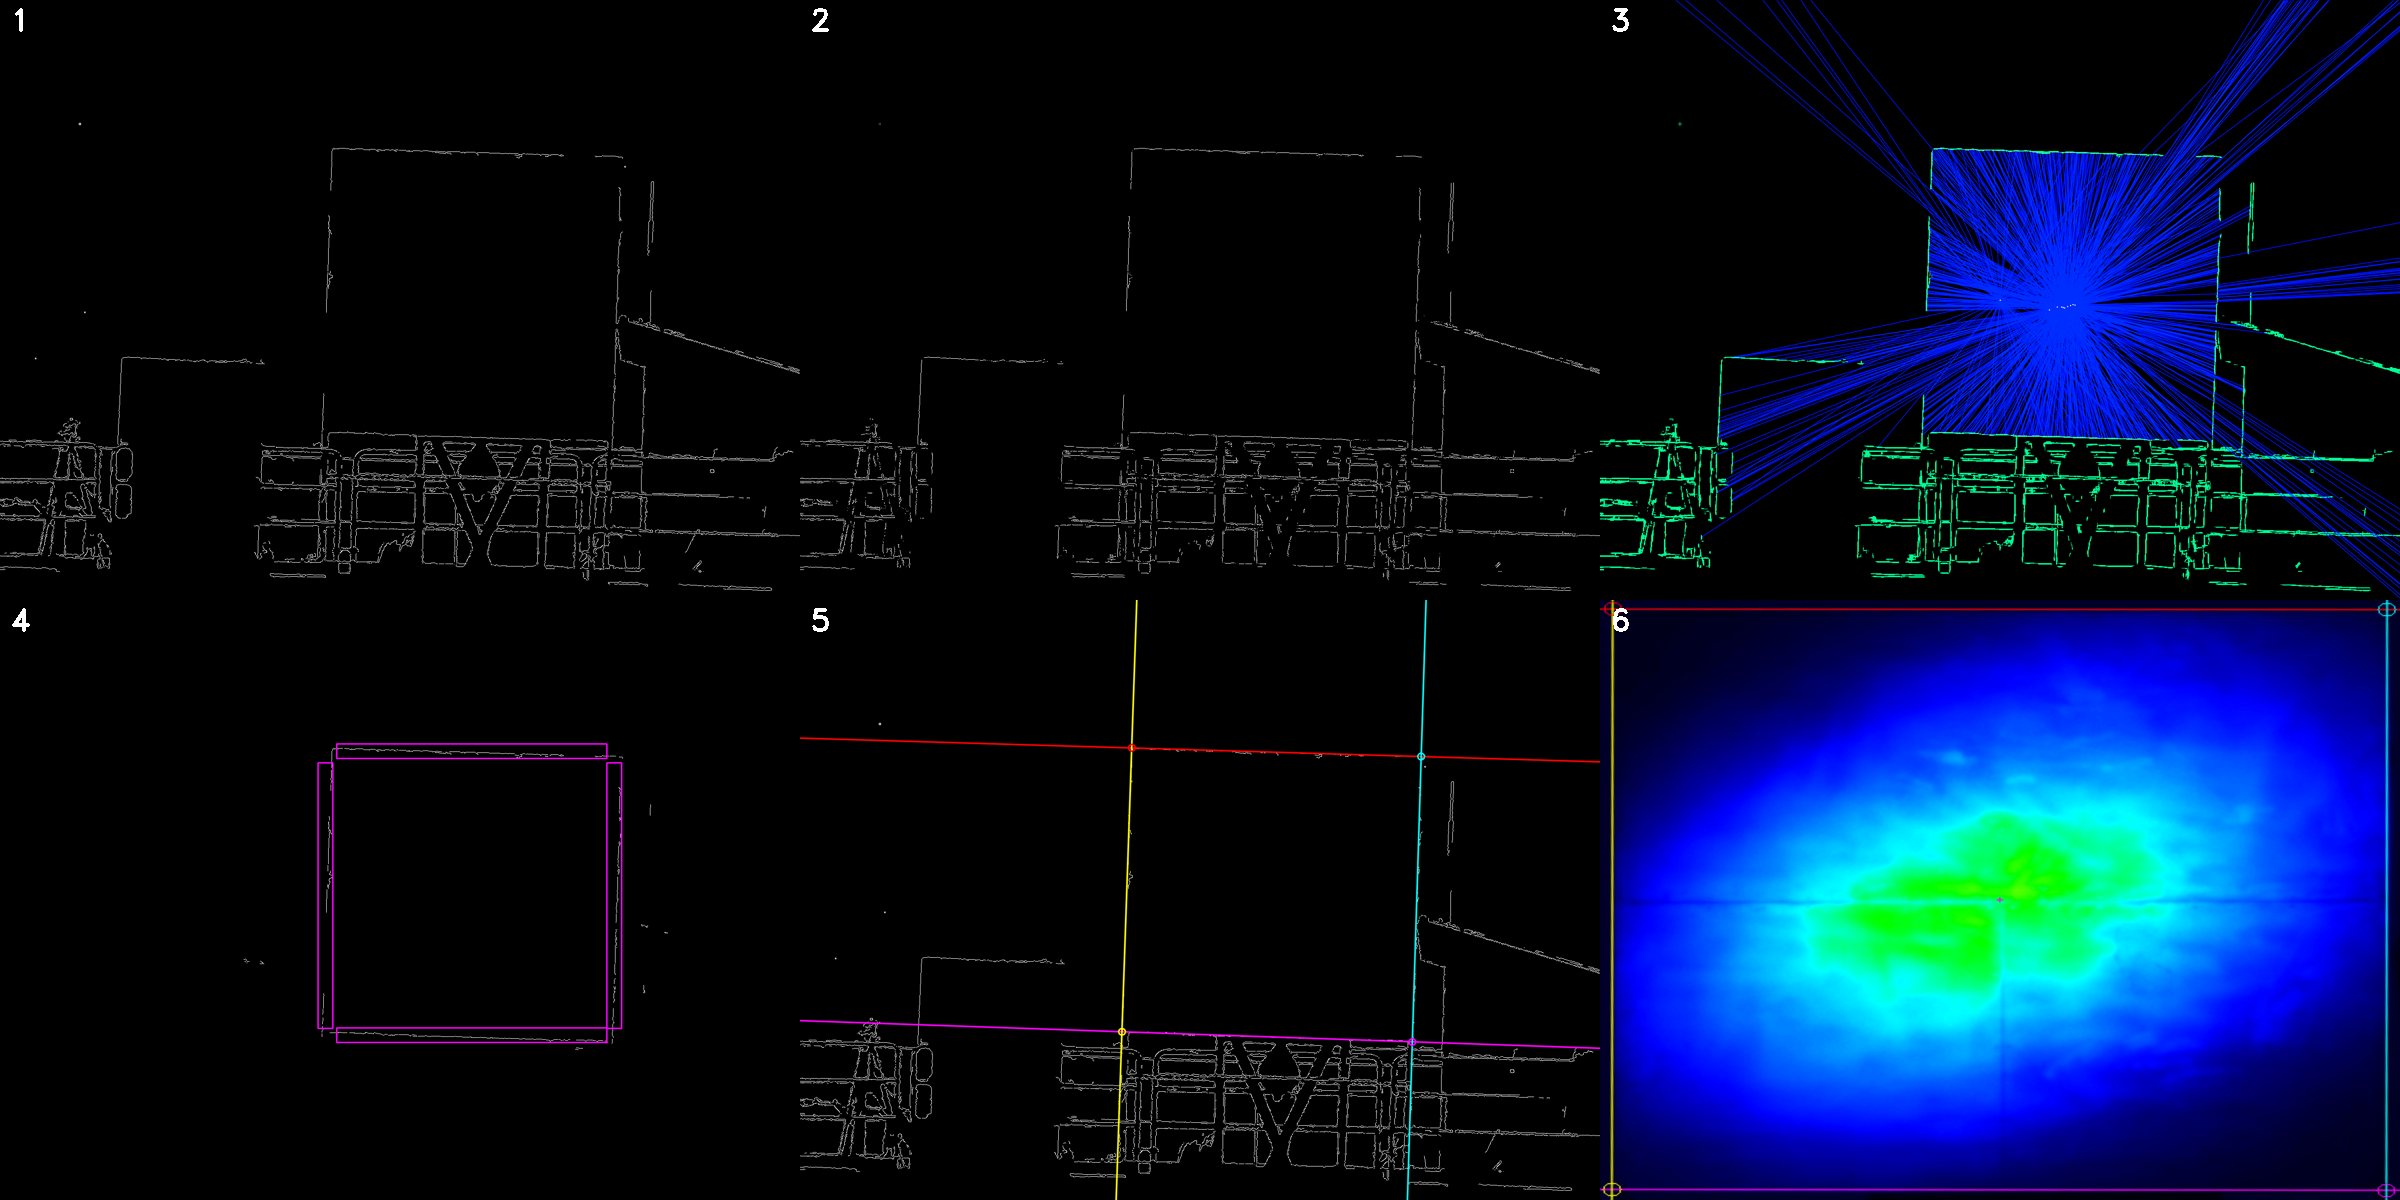

In [9]:
best_canny_edges_gradient = 6
best_canny_non_edges_gradient = 2
tbl_proc = TargetBoardLocatorImageProcessor(
    reference_image_dir_or_file=nosun_img_file,
    cropped_x1x2y1y2=None,
    target_width_meters=uc.foot_to_meter(8),
    target_height_meters=uc.foot_to_meter(8),
    canny_edges_gradient=best_canny_edges_gradient,
    canny_non_edges_gradient=best_canny_non_edges_gradient,
    edge_coarse_width=30,
    generate_region_detector_powerpoint=False,
)

spot_analysis_canny = sa.SpotAnalysis("Target Board Locator Explainer", [tbl_proc])
spot_analysis_canny.set_primary_images([onsun_img_file])
processed = next(iter(spot_analysis_canny))
cropped_target_image = processed.primary_image

# get the visualization and algorithm images
visualization_images = processed.visualization_images[tbl_proc]
algorithm_images = processed.algorithm_images[tbl_proc]

# add color channels to any grayscale images, so that the preview below works correctly
visualization_images = map(lambda img: it.to_image(img, "numpy"), visualization_images)
algorithm_images = map(lambda img: it.to_image(img, "numpy"), algorithm_images)
visualization_images = list(map(lambda img: ir.nchannels_reshaper(img, 3), visualization_images))
algorithm_images = list(map(lambda img: ir.nchannels_reshaper(img, 3), algorithm_images))

# preview the visualization and algorithm images
images_list = algorithm_images + visualization_images
print(
    "\nTop-left 1 Canny, middle 2 edge pixels, right boundary pixels/ray casting"
    + "\nBottom-Left 4 boundary grouping, middle 5 RanSaC edge assignment, right 6 perspective transform"
)

ig.ImageGrid(
    (3, 2),
    *images_list,
    subimage_size=(800, 600),
    number_images=True,
    numbering_color=clr.white()
).tile_images()

Next we will inpaint the image to remove seams in the target board. The target is composed of three sheets of aluminum, with a 8'x4' top sheet and two 4'x4' bottom sheets. Where the sheets meet and where the screws join the sheets to the backing structure there is less light reflected. We mask out the intersection points and screws in order to simplify the next steps in our analysis.

In InpaintImageProcessor.get_num_marchin_edges_iterations: mask width/height: 56
Loading corner mask scales from C:\ctemp\OpenCSP_example_data\target_identification\output\inpaint_cache

Left 1 inpainting mask, middle 2 target board, right inpainted target board


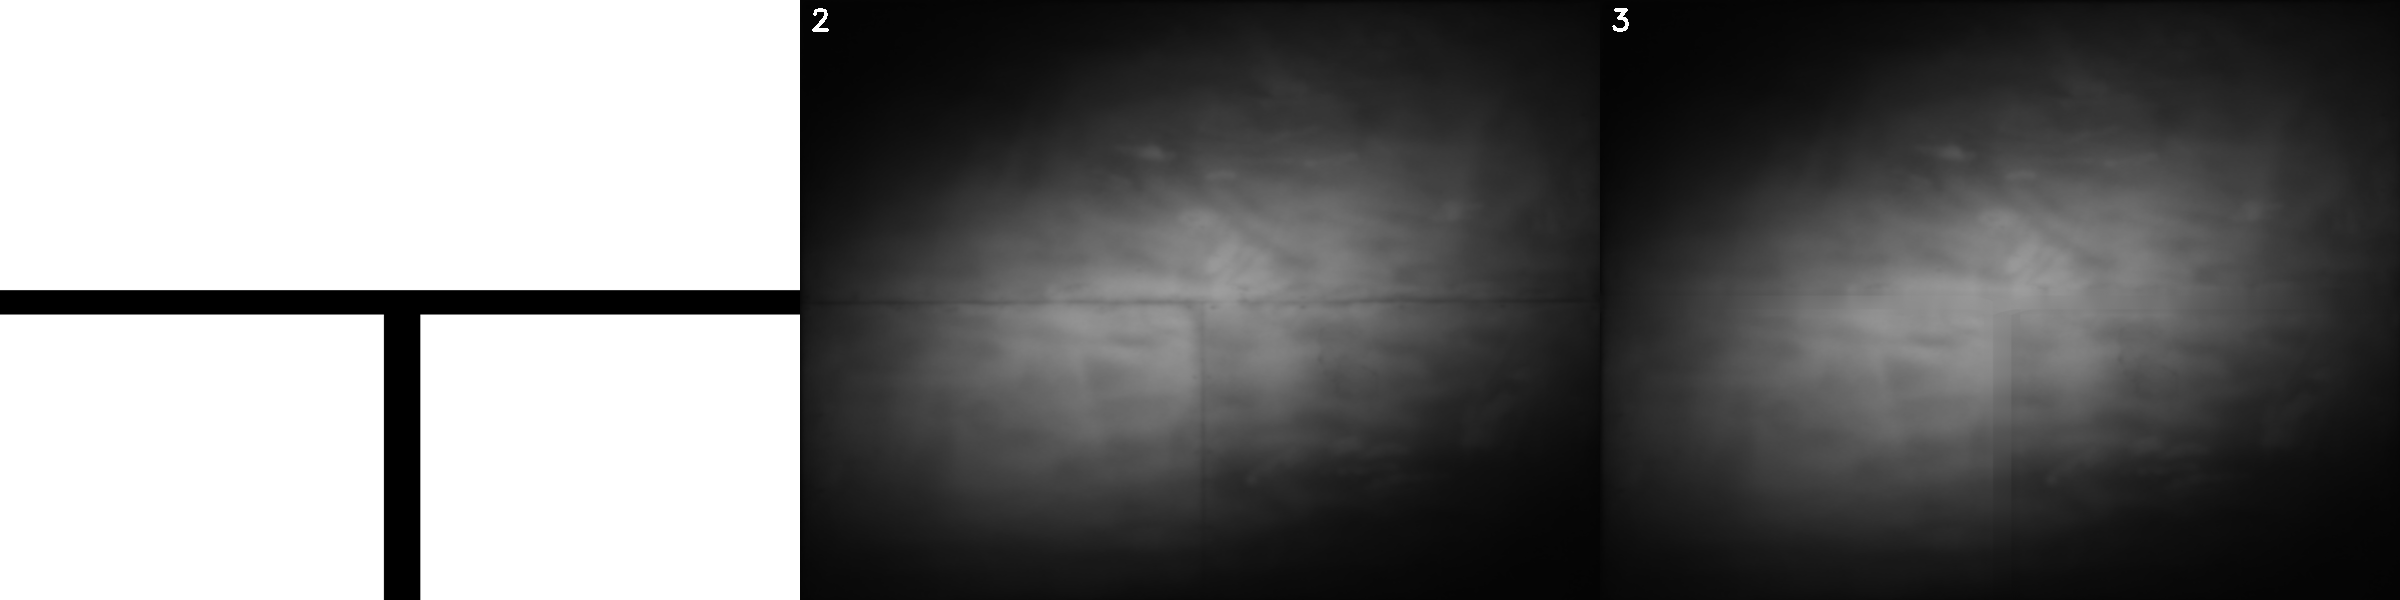

In [10]:
mask_image = Image.open(mask_image_path_name_ext)
inpaint_proc = InpaintImageProcessor(mask_image_path_name_ext, cache_dir=os.path.join(output_dir, "inpaint_cache"))

spot_analysis_inpaint = sa.SpotAnalysis("Inpainting Explainer", [inpaint_proc])
spot_analysis_inpaint.set_primary_images([cropped_target_image])
processed = next(iter(spot_analysis_inpaint))
inpainted_image = processed.primary_image

# preview the visualization and algorithm images
images_list = [mask_image, cropped_target_image, inpainted_image]
print("\nLeft 1 inpainting mask, middle 2 target board, right inpainted target board")

ig.ImageGrid(
    (3, 1),
    *images_list,
    subimage_size=(800, 600),
    number_images=True,
    numbering_color=clr.white()
).tile_images()

The following cell shows the full processing pipeline. This is a description for what each processor in the pipeline does:

* `EchoImageProcessor`: indicate that an image has started being processed
* `PopulationStaticsImageProcessor`: necessary for establishing the brightness range for some visualization image processors
* `TargetLocationImageProcessor`: locates the target board and crops the image in to the target board
* `InpaintImageProcessor`: fills in gaps left by physical marks on the target with linear-fit data
* `HotspotImageProcessor`: locates the center of the spot by "zooming in" on the hottest portion of the image
* `ViewFalseColorImageProcessor`: converts a grayscale image into a rainbow to make it easier to distinguish lights and darks, where darker values are closer to black and lighter values are closer to white
* `ViewAnnotationsImageProcessor`: visualizes all annotations attached to an image. In this situation, that will include annotations from the hotspot image processor
* `ViewHighlightImageProcessor`: visualizes white pixels as cyan, and black pixels as magenta.
* `ViewCrossSectionImageProcessor`: visualizes the horizontal and vertical cross sections of the image.

Note: the visualization image processors have the option for choosing which image they build on. "Primary" would be the main image being processed and is the default. "Visualization" is the last visualization image, so in this case that means that the centroid visualization build on top of the highlight visualization, which in turn builds on top of the false color visualization.

We also add a powerpoint image processor to generate a powerpoint deck explaining how we got the result that we did. It will, for each result produced, plot the steps in it's configured outline (one slide per processors_per_slide entry).

Number of processors: 15
test:  Target Identification
Processing image 9E10_onsun_avg.png
In AverageByGroupImageProcessor._execute_aggregate(): averaging 1 images
Saving temporary image to:     C:\Users\rcbrost\AppData\Local\opencsp\scratch\tmp\PowerpointImage\images\tmp\0_31.png
Saving temporary image to:     C:\Users\rcbrost\AppData\Local\opencsp\scratch\tmp\PowerpointImage\images\tmp\0_32.png
Saving temporary image to:     C:\Users\rcbrost\AppData\Local\opencsp\scratch\tmp\PowerpointImage\images\tmp\0_33.png
Saving temporary image to:     C:\Users\rcbrost\AppData\Local\opencsp\scratch\tmp\PowerpointImage\images\tmp\0_34.png
Saving temporary image to:     C:\Users\rcbrost\AppData\Local\opencsp\scratch\tmp\PowerpointImage\images\tmp\0_35.png
Saving temporary image to:     C:\Users\rcbrost\AppData\Local\opencsp\scratch\tmp\PowerpointImage\images\tmp\0_36.png
Sampled 680 points
Saving temporary image to:     C:\Users\rcbrost\AppData\Local\opencsp\scratch\tmp\PowerpointImage\images\tmp\0

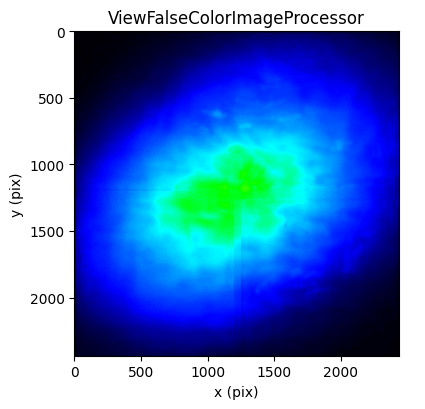

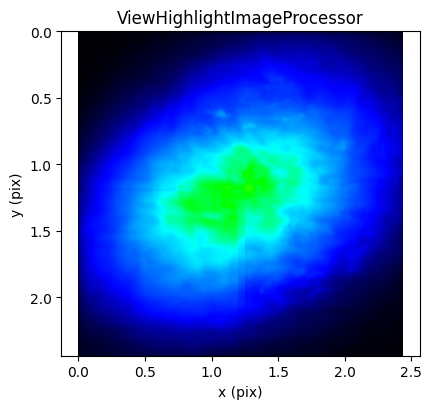

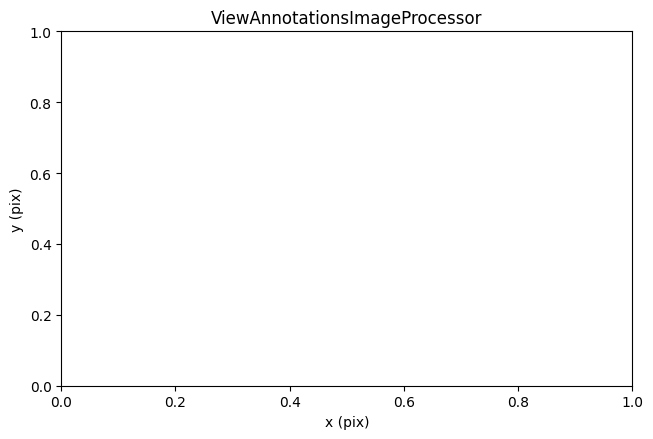

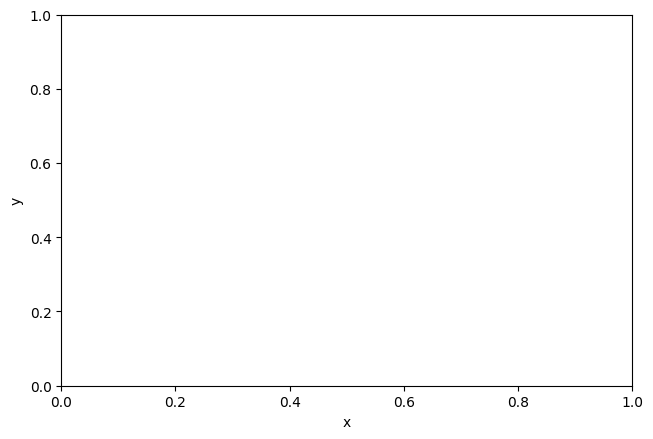

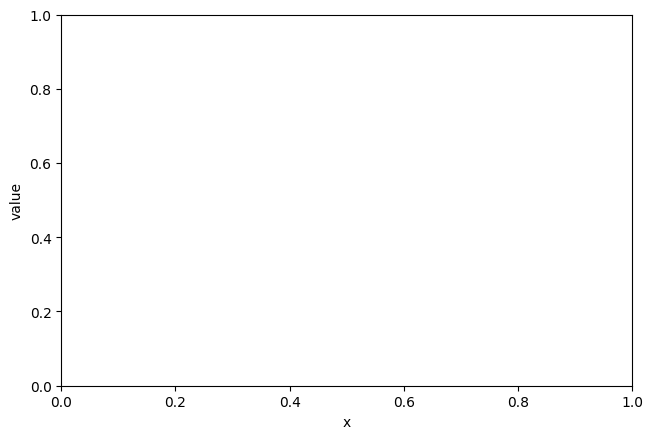

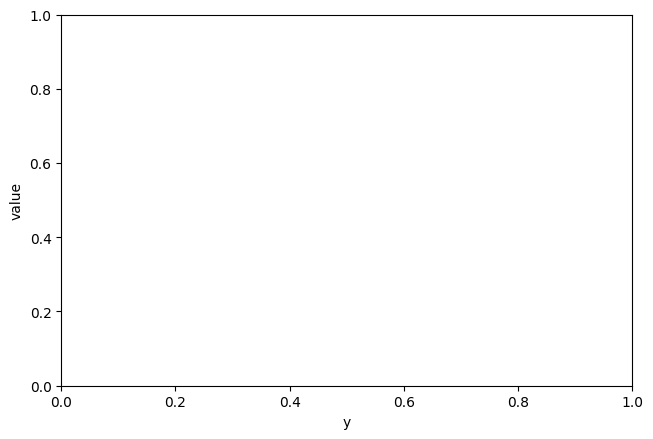

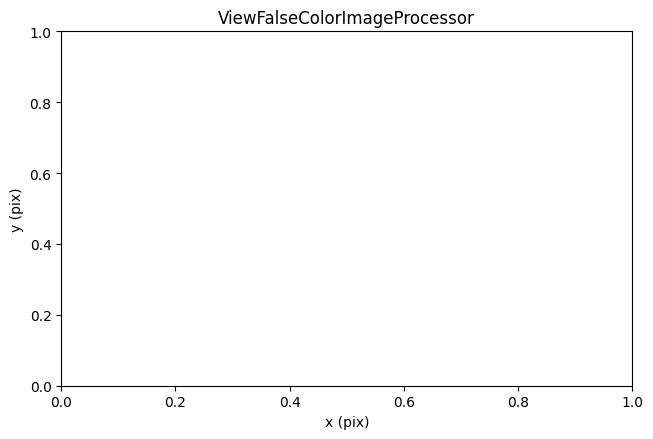

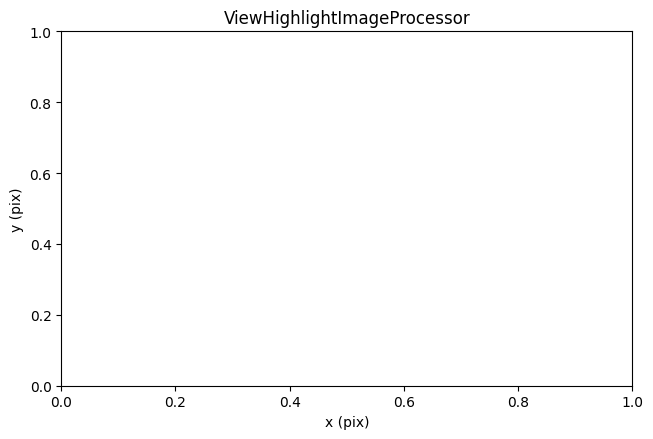

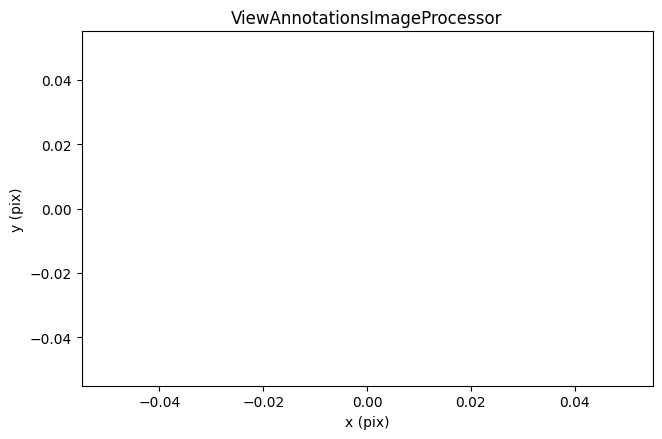

Percentage of interest 0.5 is at radius 667
Percentage of interest 0.8 is at radius 981
Percentage of interest 0.9 is at radius 1125


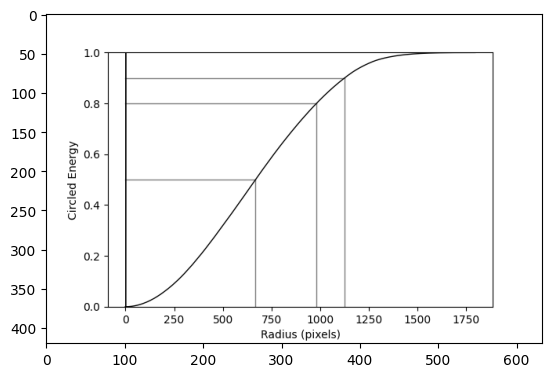

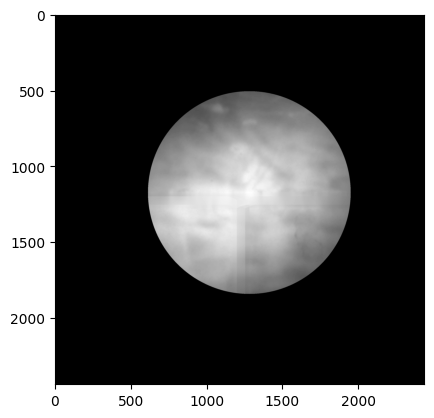

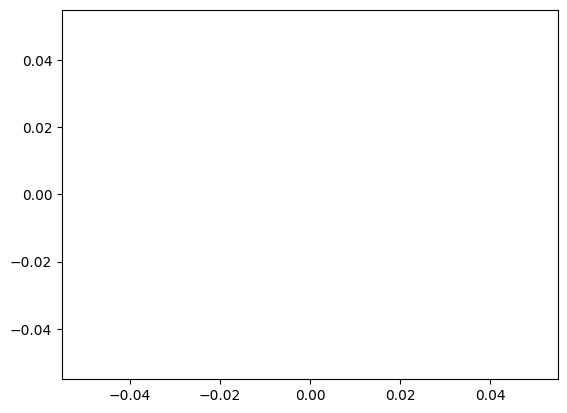

len(self.p2r[0])=3
self.p2r[1]=[667, 981, 1125]
Saving temporary image to:     C:\Users\rcbrost\AppData\Local\opencsp\scratch\tmp\PowerpointImage\images\tmp\1_15.png
Saving persistent image to:    C:\ctemp\OpenCSP_example_data\target_identification\output\PowerPointFigures\1_15.png
Saving persistent metadata to: C:\ctemp\OpenCSP_example_data\target_identification\output\PowerPointFigures\1_15.txt
Saving temporary image to:     C:\Users\rcbrost\AppData\Local\opencsp\scratch\tmp\PowerpointImage\images\tmp\1_16.png
Saving persistent image to:    C:\ctemp\OpenCSP_example_data\target_identification\output\PowerPointFigures\1_16.png
Saving persistent metadata to: C:\ctemp\OpenCSP_example_data\target_identification\output\PowerPointFigures\1_16.txt
Saving temporary image to:     C:\Users\rcbrost\AppData\Local\opencsp\scratch\tmp\PowerpointImage\images\tmp\1_17.png
Saving persistent image to:    C:\ctemp\OpenCSP_example_data\target_identification\output\PowerPointFigures\1_17.png
Saving persis

In [11]:
def get_hotspot(operable: sao.SpotAnalysisOperable) -> tuple[int, int]:
    h: hanno.HotspotAnnotation = operable.get_fiducials_by_type(hanno.HotspotAnnotation)[0]
    return h.origin.x, h.origin.y


get_center = get_hotspot

# Build the image processing pipeline from our sequential set of processors.
procs = {
    "Echo": EchoImageProcessor(),
    "Population": PopulationStatisticsImageProcessor(),
    "SubNull": NullImageSubtractionImageProcessor(np.array(nosun_img)),
    "CropTarget": TargetBoardLocatorImageProcessor(
        reference_image_dir_or_file=nosun_img_file,
        cropped_x1x2y1y2=None,
        target_width_meters=uc.foot_to_meter(8),
        target_height_meters=uc.foot_to_meter(8),
        canny_edges_gradient=best_canny_edges_gradient,
        canny_non_edges_gradient=best_canny_non_edges_gradient,
        edge_coarse_width=30,
    ),
    "Inpaint": InpaintImageProcessor(mask_image_path_name_ext, cache_dir=os.path.join(output_dir, "inpaint_cache")),
    "Hotspot": HotspotImageProcessor(desired_shape=31),
    "VFalseColr": ViewFalseColorImageProcessor(),
    "VHighlight": ViewHighlightImageProcessor(base_image_selector="Visualization"),
    "VHotspot": ViewAnnotationsImageProcessor(base_image_selector="Visualization"),
    "VCrossSec": ViewCrossSectionImageProcessor(
        get_center, single_plot=False, y_range=[0, 255], plot_title="Cross Section"
    ),
    "EncircledEnergy": EnclosedEnergyImageProcessor(
        get_center, enclosed_shape="circle", percentages_of_interest=[0.5, 0.8, 0.9]
    ),
    "VFalseColr2": ViewFalseColorImageProcessor(),
    "VHighlight2": ViewHighlightImageProcessor(base_image_selector="Visualization"),
    "VEnclEnergy": ViewAnnotationsImageProcessor(
        annotations_filter=[eeanno.EnclosedEnergyAnnotations], base_image_selector="Visualization"
    ),
}

# Add in the powerpoint image processor. We do this in a second
# step so that we can reference the other image processors in the
# powerpoint slide deck.
procs["Powerpoint"] = PowerpointImageProcessor(
    save_dir=output_dir,
    save_name="target_identification",
    overwrite=True,
    processors_per_slide=[
        [(procs["Population"], "Original Image"), procs["SubNull"]],
        [procs["CropTarget"]],
        [procs["Inpaint"]],
        [(procs["VHighlight"], "False Color"), (procs["VHotspot"], "Hotspot"), procs["VCrossSec"]],
        [(procs["EncircledEnergy"], "Encircled Energy"), (procs["VEnclEnergy"], "Encircled Energy")],
    ],
    persistent_save_path = os.path.join(output_dir, "PowerPointFigures")
)

# Build the spot analysis instance and evaluate.
spot_analysis_target_identification = sa.SpotAnalysis(
    "Target Identification", list(procs.values()), output_dir, save_overwrite=False
)
spot_analysis_target_identification.set_primary_images([onsun_img_file])
print(f"Number of processors: {len(procs)}")
print("test: ", spot_analysis_target_identification.name)
for processed in spot_analysis_target_identification:
    pass

Results
-------

Now that processing is all done we will print out the path to the generated powerpoint deck, the pixel radius that envelopes the percentage of interest (poi) total enclosed energy, and some of the more interesting images.

The Powerpoint slide deck is saved to C:\ctemp\OpenCSP_example_data\target_identification\output\target_identification.pptx
Radius for 50% encircled energy: 667px
Radius for 80% encircled energy: 981px
Radius for 90% encircled energy: 1125px
Top-left 1 cross section location, right 2 horizontal cross section
Bottom-left 3 vertical cross section, right 4 encircled energy


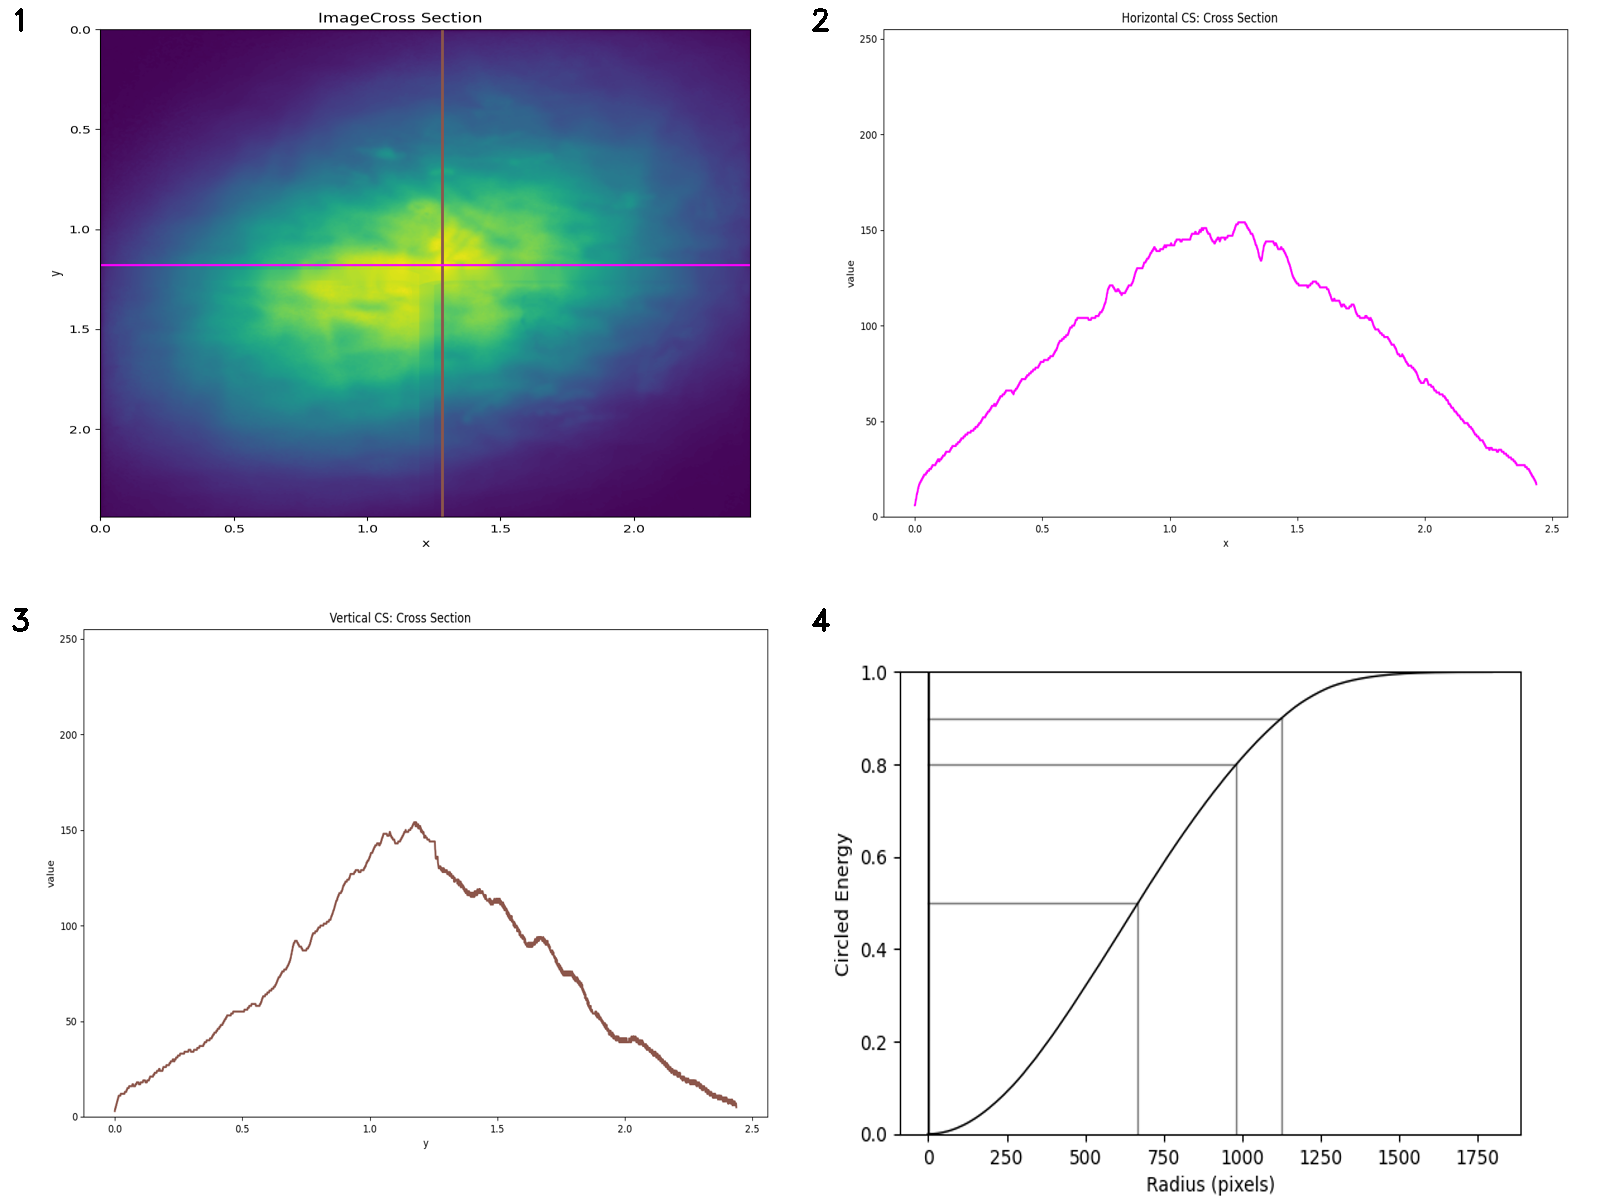

In [12]:
# Get the results
print(f"The Powerpoint slide deck is saved to {procs['Powerpoint'].dest_path_name_ext}")

all_processors_notes = processed.image_processor_notes
enclosed_energy_notes = list(filter(lambda notes: "Enclosed" in notes[0], all_processors_notes))[0]
processor_name, data = enclosed_energy_notes
percentages_of_interest, enclosed_energy_by_radius = data
for poi in percentages_of_interest:
    print(f"Radius for {int(poi*100)}% encircled energy: {percentages_of_interest[poi]}px")

cross_section_over_img = processed.visualization_images[procs["VCrossSec"]][0]
cross_section_hor_img = processed.visualization_images[procs["VCrossSec"]][1]
cross_section_vert_img = processed.visualization_images[procs["VCrossSec"]][2]
encircled_energy_img = processed.visualization_images[procs["EncircledEnergy"]][-1]
images_list = [cross_section_over_img, cross_section_hor_img, cross_section_vert_img, encircled_energy_img]
images_list = [ir.nchannels_reshaper(it.to_image(img), 3) for img in images_list]
print(
    "Top-left 1 cross section location, right 2 horizontal cross section\nBottom-left 3 vertical cross section, right 4 encircled energy"
)
ig.ImageGrid(
    (2, 2),
    *images_list,
    subimage_size=(800, 600),
    number_images=True,
    numbering_outline_color=clr.white()
).tile_images()